<a href="https://colab.research.google.com/github/artport-max/AIFFEL_quest_eng/blob/main/NLP/NLP01/%ED%95%9C%EC%98%81%EB%B2%88%EC%97%AD02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$ mkdir -p ~/work/s2s_translation

In [ ]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
104 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tre

## matplotlib 한글 폰트 설정

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [ ]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random
import unicodedata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(device)

2.10.0+cu128
cuda


In [ ]:
import tarfile

dataset_dir = os.path.expanduser("~/work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")
path_to_ko = os.path.join(dataset_dir, "korean-english-park.train.ko")
path_to_en = os.path.join(dataset_dir, "korean-english-park.train.en")

if os.path.exists(path_to_ko) and os.path.exists(path_to_en):
    print("이미 다운로드 & 압축 해제 완료된 상태예요!")
else:
    # tar.gz가 없으면 다운로드
    if not os.path.exists(tar_path):
        print("데이터 다운로드 중...")
        url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
        urllib.request.urlretrieve(url, tar_path)
        print("다운로드 완료!")

    # 압축 해제 (이미 풀려있어도 강제로 다시 풀어도 문제는 없지만, 위 조건으로 거의 실행 안 됨)
    print("tar.gz 압축 해제 중...")
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

print("데이터셋 디렉토리 내용:", os.listdir(dataset_dir))
print("한국어 파일:", path_to_ko)
print("영어 파일  :", path_to_en)

이미 다운로드 & 압축 해제 완료된 상태예요!
데이터셋 디렉토리 내용: ['korean-english-park.train.tar.gz', 'korean-english-park.train.ko', 'korean-english-park.train.en']
한국어 파일: /root/work/s2s_translation/datasets/korean-english-park.train.ko
영어 파일  : /root/work/s2s_translation/datasets/korean-english-park.train.en


In [ ]:
import random

def verify_alignment(ko_path, en_path, set_name):
    with open(ko_path, 'r', encoding='utf-8') as f:
        ko_lines = [line.strip() for line in f if line.strip()]
    with open(en_path, 'r', encoding='utf-8') as f:
        en_lines = [line.strip() for line in f if line.strip()]

    print(f"=== {set_name} Set Alignment Check ===")
    # 1. 라인 수 비교
    is_count_match = len(ko_lines) == len(en_lines)
    print(f"Line Count Match: {is_count_match} (KO: {len(ko_lines)}, EN: {len(en_lines)})")

    if not is_count_match:
        print("Warning: Line counts do not match!")

    # 2. 무작위 샘플링 검증 (3개 쌍)
    print(f"\n[Random Samples from {set_name}]")
    sample_size = min(len(ko_lines), len(en_lines), 3)
    indices = random.sample(range(min(len(ko_lines), len(en_lines))), sample_size)

    for i, idx in enumerate(indices):
        print(f"{i+1}. [Index {idx}]")
        print(f"   KO: {ko_lines[idx]}")
        print(f"   EN: {en_lines[idx]}")
    print("=" * 50 + "\n")

# 파일 경로 설정
sets_to_verify = [
    ('/content/korean-english-park.train.ko', '/content/korean-english-park.train.en', 'Train'),
    ('/content/korean-english-park.dev.ko', '/content/korean-english-park.dev.en', 'Dev'),
    ('/content/korean-english-park.test.ko', '/content/korean-english-park.test.en', 'Test')
]

for ko, en, name in sets_to_verify:
    verify_alignment(ko, en, name)

=== Train Set Alignment Check ===
Line Count Match: True (KO: 94123, EN: 94123)

[Random Samples from Train]
1. [Index 77469]
   KO: 5시간이 지난 후, 여섯 명의 수사관들이 네 개의 커다란 서류 상자와 두 개의 노트북 컴퓨터, 그리고 공구 상자를 들고 사무실을 떠났다.
   EN: After five hours, six investigators left the compound carrying four large manila envelopes, two laptop computer cases and a tool box.
2. [Index 8982]
   KO: 사드르시티와 바그다드 신시가지는 시아파 거주지역이다. 사드르시티에서는 최근까지 미군 및 이라크군과 무장세력간에 치열한 교전이 벌어졌던 곳이다.
   EN: Both Sadr City and New Baghdad are largely Shiite, and fighting raged for weeks in Sadr City between troops and militants until a recent peace deal took hold.
3. [Index 18364]
   KO: 한편 학교관계자는 게시판을 통해 학생들에게 부모에게 연락을 취하라고 요구했다.
   EN: He started with a shotgun, then turned to a pistol.

=== Dev Set Alignment Check ===
Line Count Match: True (KO: 1000, EN: 1000)

[Random Samples from Dev]
1. [Index 804]
   KO: 한편 헤즈볼라가 발사한 로켓 중 한발은 서부 해안의 나하리야 마을에 떨어져 한명이 사망하였고 이로써 교전이 시작된 이래 사망한 많은 수의 이스라엘 시민이 사망했다.
   EN: One rocket killed a man near

## 데이터 전처리

In [ ]:
# 1. 공통 전처리: 기호 통일, URL/이메일 제거, 공백 정제
def preprocess_common(text):
    # 유니코드 정규화 (NFKC: 결합된 글자들을 표준 형태로 통일)
    text = unicodedata.normalize('NFKC', text)

    # 이메일 및 URL 제거
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 스마트 따옴표, 백틱 등을 표준 따옴표로 통일
    text = re.sub(r"[“”„]", '"', text)
    text = re.sub(r"[‘’´`]", "'", text)

    # 하이픈, 대시 통일
    text = re.sub(r"[—–-]", "-", text)

    # 불필요한 특수문자 제거 (별표, 밑줄 등)
    text = re.sub(r"[\*_]", " ", text)

    # 연속된 공백 하나로 통일
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 2. 한국어 특화 전처리
def preprocess_ko(text):
    # 뉴스 메타 텍스트 제거 (기자명, 출처 괄호 등)
    text = re.sub(r"[가-힣]{2,4}\s*기자", " ", text)
    text = re.sub(r"\([^)]*(뉴스|로이터|AP|AFP|통신|연합|JOINS)[^)]*\)", " ", text)

    # 한글, 영어, 숫자, 기본 구두점만 남기기
    text = re.sub(r"[^가-힣a-zA-Z0-9?.!,()\"']+", " ", text)
    return text.strip()

# 3. 영어 특화 전처리
def preprocess_en(text):
    # 소문자 변환
    text = text.lower()

    # 뉴스 메타 텍스트 제거 (By..., Reuters/AP 괄호 등)
    text = re.sub(r"by\s+[a-zA-Z]+\s+[a-zA-Z]+", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\([^)]*(reuters|ap|afp|news)[^)]*\)", " ", text, flags=re.IGNORECASE)

    # 영어, 숫자, 기본 구두점만 남기기
    text = re.sub(r"[^a-zA-Z0-9?.!,()\"']+", " ", text)
    return text.strip()

# 3-1. 영어 start, end 추가
def preprocess_en_with_tokens(text):
    text = preprocess_en(text) # 사용자님이 만든 고퀄리티 정제 코드 그대로 사용
    return f"<start> {text} <end>"

# 4. 정렬 필터링 (Alignment & Ratio Check)
def is_good_pair(ko_text, en_text):
    # 어느 한쪽이라도 비어있으면 탈락
    if not ko_text or not en_text:
        return False

    # 길이 기반 필터링 (글자 수 기준)
    ko_len = len(ko_text)
    en_len = len(en_text)

    # 너무 짧은 문장 제거 (의미 없는 조각들)
    if ko_len < 2 or en_len < 2:
        return False

    # 길이 비율 체크 (한 문장이 다른 문장보다 지나치게 길면 잘못된 매칭일 확률 높음)
    # 일반적으로 한국어 대비 영어 글자 수 비율은 0.5 ~ 3.0 사이가 적당합니다.
    ratio = ko_len / en_len
    if ratio < 0.3 or ratio > 3.5:
        return False

    return True

In [ ]:
import pandas as pd
import random
import os

def load_and_verify(ko_path, en_path, set_name):
    with open(ko_path, 'r', encoding='utf-8') as f:
        ko_lines = [line.strip() for line in f if line.strip()]
    with open(en_path, 'r', encoding='utf-8') as f:
        en_lines = [line.strip() for line in f if line.strip()]

    # Basic Stats
    stats = []
    for lang, lines, path in [('KO', ko_lines, ko_path), ('EN', en_lines, en_path)]:
        avg_words = sum(len(line.split()) for line in lines) / len(lines) if lines else 0
        stats.append({
            'Set': set_name,
            'Language': lang,
            'File': os.path.basename(path),
            'Lines': len(lines),
            'Avg Word Count': round(avg_words, 2)
        })

    # Alignment Check
    is_aligned = len(ko_lines) == len(en_lines)
    print(f'\n[ {set_name} Alignment Check ]')
    print(f'Line counts match: {is_aligned} (KO: {len(ko_lines)}, EN: {len(en_lines)})')

    # Random Sampling
    if is_aligned and len(ko_lines) > 0:
        print(f'Sampling 3 pairs from {set_name}:')
        indices = random.sample(range(len(ko_lines)), 3)
        for i, idx in enumerate(indices):
            print(f' {i+1}. [Idx {idx}]')
            print(f'    KO: {ko_lines[idx]}')
            print(f'    EN: {en_lines[idx]}')

    return stats

# Define files to check
corpus_sets = sets_to_verify

all_stats = []
for ko, en, name in corpus_sets:
    all_stats.extend(load_and_verify(ko, en, name))

# Summary Table
df_integrity = pd.DataFrame(all_stats)
print('\n--- Summary Table ---')
display(df_integrity)


[ Train Alignment Check ]
Line counts match: True (KO: 94123, EN: 94123)
Sampling 3 pairs from Train:
 1. [Idx 22939]
    KO: 이 당선자는 노무현 정부로부터 정권을 인계 받게 된다.
    EN: Lee will take over from Roh Moo-Hun, who had promised reform and clean governance.
 2. [Idx 4086]
    KO: 나는 왜 한 집단이 자신의 도덕적 견해를 다른 집단에게 강요해야 하는지 그 이유를 모르겠습니다."
    EN: I don't see why one group should impose its moral view on another."
 3. [Idx 86194]
    KO: TG Computer has sought court protection.삼보 컴퓨터, 법정 관리 신청
    EN: Trigem Computer, one of the nation's largest makers of personal computers, has sought court protection after losing the competitive battle to low-cost Chinese producers and becoming weighed down by debt.

[ Dev Alignment Check ]
Line counts match: True (KO: 1000, EN: 1000)
Sampling 3 pairs from Dev:
 1. [Idx 184]
    KO: 훈센은 크메르루주 병사 출신으로 그는 23년째 권좌를 지키고 있다.
    EN: The vote is expected to usher in yet another term for the former Khmer Rouge soldier who has ruled for 23 years.
 2. [Idx 289]
    KO: 무안메르

,Set,Language,File,Lines,Avg Word Count
0,Train,KO,korean-english-park.train.ko,94123,14.05
1,Train,EN,korean-english-park.train.en,94123,20.90
2,Dev,KO,korean-english-park.dev.ko,1000,15.09
3,Dev,EN,korean-english-park.dev.en,1000,22.15
4,Test,KO,korean-english-park.test.ko,2000,15.41
5,Test,EN,korean-english-park.test.en,2000,22.84


In [ ]:
with open(path_to_ko, "r", encoding='utf-8') as f: ko_lines = f.read().splitlines()
with open(path_to_en, "r", encoding='utf-8') as f: en_lines = f.read().splitlines()

In [ ]:
# 데이터프레임 생성 (전체 데이터)
df = pd.DataFrame({'ko': ko_lines, 'en': en_lines})

In [ ]:
print(f"중복 제거 전 데이터 개수: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"중복 제거 후 데이터 개수: {len(df)}")

중복 제거 전 데이터 개수: 94123
중복 제거 후 데이터 개수: 78968


In [ ]:
# df = df[:30000] 나중에..

df['ko'] = df['ko'].apply(preprocess_common).apply(preprocess_ko)
df['en'] = df['en'].apply(preprocess_common).apply(preprocess_en_with_tokens)

df.head()

,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""",<start> start much of personal computing is ab...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,<start> start so a mention a few weeks ago abo...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"<start> start like all optical mice, but it al..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",<start> start uses gyroscopic sensors to contr...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,<start> start intelligence officials have reve...


## 2차 중복 제거 (전처리 결과 똑같아진 것들 정리)

In [ ]:
df.drop_duplicates(inplace=True)
print(f"중복 제거 후 데이터 개수: {len(df)}")

중복 제거 후 데이터 개수: 78866


In [ ]:
# 정렬 필터링 적용 (조건에 맞는 행만 남김)
mask = df.apply(lambda row: is_good_pair(row['ko'], row['en']), axis=1)
filtered_df = df[mask].copy()

print(f"필터링 전: {len(df)}개")
print(f"필터링 후: {len(filtered_df)}개")

필터링 전: 78866개
필터링 후: 67483개


## 문장 길이 필터링

In [ ]:
def length_filter(ko_text, en_text, min_words=3, max_words=99):
    ko_len = len(ko_text.split())
    en_len = len(en_text.split())
    # Return True only if both satisfy the condition
    return (min_words <= ko_len <= max_words) and (min_words <= en_len <= max_words)

filtered_data = {}

print("--- Sentence Length Filtering Results ---")

# Apply the length filter to the existing filtered_df (which contains the 'Train' data)
initial_count = len(filtered_df)
mask_length_filter = filtered_df.apply(lambda row: length_filter(row['ko'], row['en']), axis=1)
final_filtered_df = filtered_df[mask_length_filter].copy()

# Store the result in filtered_data, treating it as the 'Train' set
filtered_data['Train'] = {'ko': final_filtered_df['ko'].tolist(), 'en': final_filtered_df['en'].tolist()}

final_count = len(final_filtered_df)
print(f"[Train Set] Pre-filtered: {initial_count} -> Post-filtered: {final_count} (Removed: {initial_count - final_count})")


--- Sentence Length Filtering Results ---
[Train Set] Pre-filtered: 67483 -> Post-filtered: 67462 (Removed: 21)


/tmp/ipython-input-450/1571593374.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='File', y='Lines', data=df_integrity, palette='viridis')


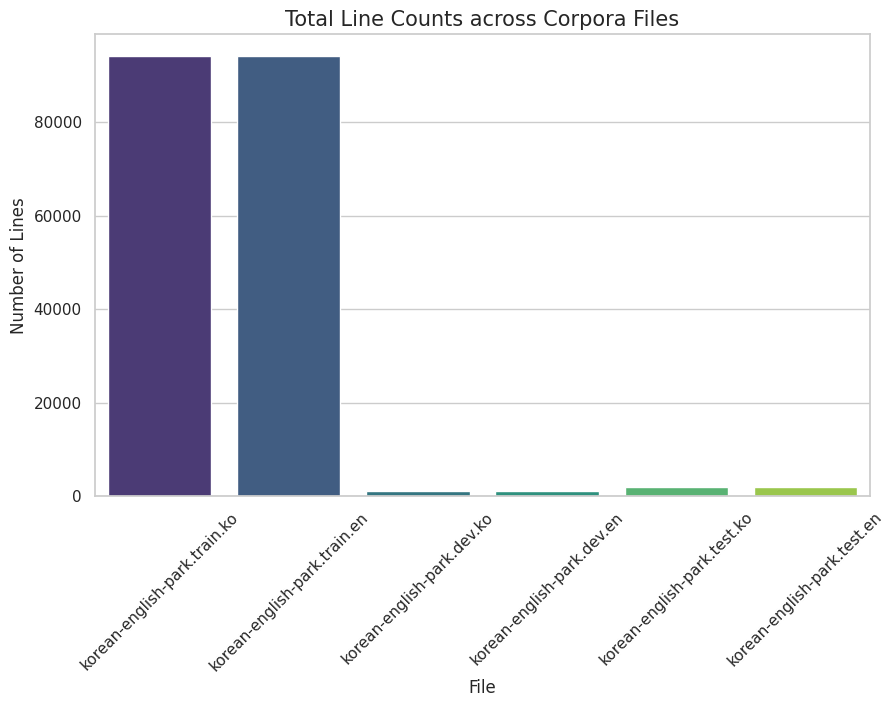

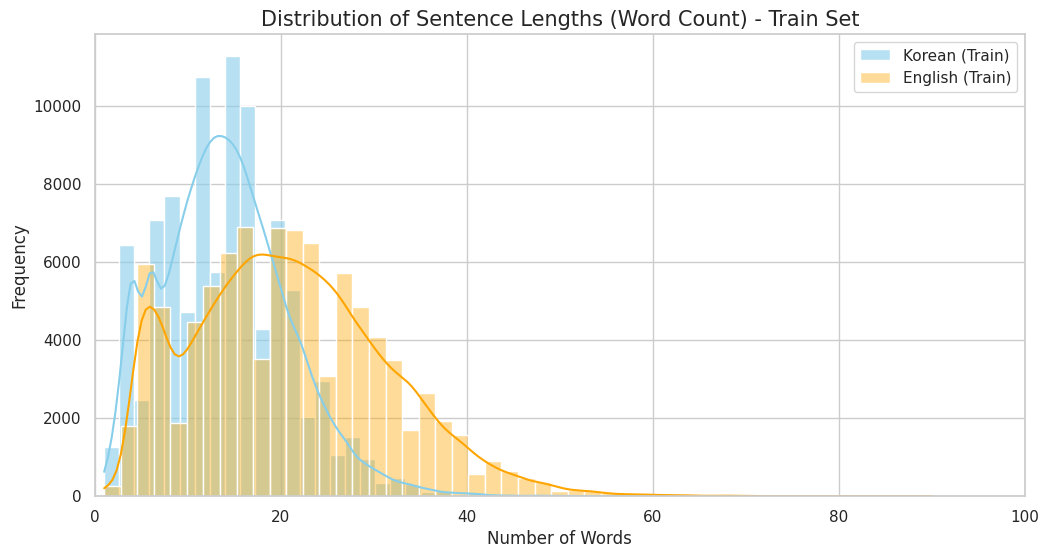

--- Summary of Findings ---
1. Data Scale: The Training set is significantly larger (94123 lines) compared to Dev (1,000) and Test (2,000) sets.
2. Length Distribution: English sentences generally have a higher average word count (~20.9) compared to Korean (~14.05).
3. (Note: Duplicates were removed in the preprocessing step, reducing the initial dataset size.)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for the plots
sns.set(style="whitegrid")

# 1. Visualize Data Sizes (Line Counts)
plt.figure(figsize=(10, 6))
sns.barplot(x='File', y='Lines', data=df_integrity, palette='viridis')
plt.title('Total Line Counts across Corpora Files', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Number of Lines')
plt.show()

# 2. Compare Sentence Length Distributions (Word Counts) for Train Set
# We need to extract word counts for train.ko and train.en
def get_word_counts(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [len(line.strip().split()) for line in f if line.strip()]

train_ko_counts = get_word_counts('/content/korean-english-park.train.ko')
train_en_counts = get_word_counts('/content/korean-english-park.train.en')

plt.figure(figsize=(12, 6))
sns.histplot(train_ko_counts, color="skyblue", label="Korean (Train)", kde=True, bins=50, alpha=0.6)
sns.histplot(train_en_counts, color="orange", label="English (Train)", kde=True, bins=50, alpha=0.4)
plt.title('Distribution of Sentence Lengths (Word Count) - Train Set', fontsize=15)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 100) # Limiting x-axis for better visibility of the bulk of data
plt.show()

# 3. Summary Findings
print("--- Summary of Findings ---")
print(f"1. Data Scale: The Training set is significantly larger ({df_integrity.iloc[0]['Lines']} lines) compared to Dev (1,000) and Test (2,000) sets.")
print(f"2. Length Distribution: English sentences generally have a higher average word count (~{df_integrity.iloc[1]['Avg Word Count']}) compared to Korean (~{df_integrity.iloc[0]['Avg Word Count']}).")
# The original code had a placeholder for 'Duplicates' which is not in df_integrity. I will remove this line.
print("3. (Note: Duplicates were removed in the preprocessing step, reducing the initial dataset size.)")

/tmp/ipython-input-450/1583003381.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='File', y='Lines', data=df_integrity, palette='magma')
/tmp/ipython-input-450/1583003381.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='File', y='Avg Word Count', data=df_integrity, palette='viridis')


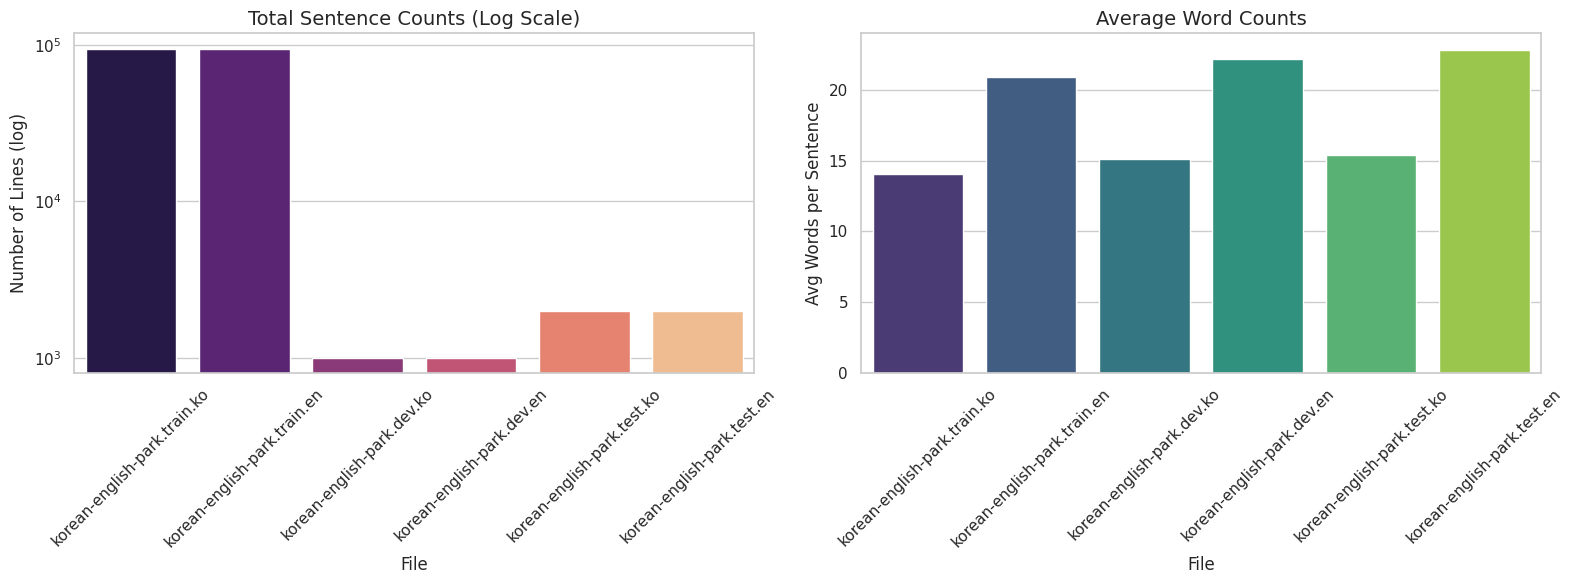

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. First subplot: Total Sentence Counts (Log Scale due to large difference in Train vs Dev/Test)
sns.barplot(ax=axes[0], x='File', y='Lines', data=df_integrity, palette='magma')
axes[0].set_yscale("log")
axes[0].set_title('Total Sentence Counts (Log Scale)', fontsize=14)
axes[0].set_ylabel('Number of Lines (log)')
axes[0].tick_params(axis='x', rotation=45)

# 4. Second subplot: Average Word Counts
sns.barplot(ax=axes[1], x='File', y='Avg Word Count', data=df_integrity, palette='viridis')
axes[1].set_title('Average Word Counts', fontsize=14)
axes[1].set_ylabel('Avg Words per Sentence')
axes[1].tick_params(axis='x', rotation=45)

# 5. & 6. Adjust layout and display
plt.tight_layout()
plt.show()

## 토큰화 전략 수립

In [ ]:
!pip install konlpy sentencepiece
print("Libraries installed successfully.")

Libraries installed successfully.


In [ ]:
from konlpy.tag import Okt
okt = Okt()
print(okt.morphs("코엔엘파이 설치가 완료되었습니다!"))

['코', '엔엘', '파이', '설치', '가', '완료', '되었습니다', '!']


In [11]:
import sentencepiece as spm
import os
import pandas as pd
import unicodedata
import re

def train_spm(corpus, model_prefix, vocab_size=10000):
    temp_file = f'{model_prefix}_temp.txt'
    with open(temp_file, 'w', encoding='utf-8') as f:
        for line in corpus:
            f.write(line + '\n')

    spm.SentencePieceTrainer.train(
        input=temp_file, model_prefix=model_prefix, vocab_size=vocab_size,
       pad_id=0, bos_id=1, eos_id=2, unk_id=3, model_type='bpe', character_coverage=1.0
    )
    os.remove(temp_file)
    return spm.SentencePieceProcessor(model_file=f'{model_prefix}.model')

# 1. Train models using filtered Training data
# Make sure filtered_data is populated from previous preprocessing steps.
# If this cell fails due to 'filtered_data' not existing, ensure previous preprocessing cells are run.

# To ensure filtered_data is always available for this cell,
# we need to re-run the filtering logic for all sets

# Define sets_to_verify here for robustness
sets_to_verify = [
    ('/content/korean-english-park.train.ko', '/content/korean-english-park.train.en', 'Train'),
    ('/content/korean-english-park.dev.ko', '/content/korean-english-park.dev.en', 'Dev'),
    ('/content/korean-english-park.test.ko', '/content/korean-english-park.test.en', 'Test')
]

filtered_data = {}
print("--- Starting Full Data Preprocessing and Filtering for SPM Training ---")

# Preprocessing functions (copied for self-containment)
def preprocess_common(text):
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}", " ", text)
    text = re.sub(r"https?://\\S+|www\\.\\S+", " ", text)
    text = re.sub(r"[“”„]", '"', text)
    text = re.sub(r"[‘’´`]", "'", text)
    text = re.sub(r"[—–-]", "-", text)
    text = re.sub(r"[\\*_]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def preprocess_ko(text):
    text = re.sub(r"[가-힣]{2,4}\\s*기자", " ", text)
    text = re.sub(r"\\([^)]*(뉴스|로이터|AP|AFP|통신|연합|JOINS)[^)]*\\)", " ", text)
    text = re.sub(r"[^가-힣a-zA-Z0-9?.!,()\"']+", " ", text)
    return text.strip()

def preprocess_en(text):
    text = text.lower()
    text = re.sub(r"by\\s+[a-zA-Z]+\\s+[a-zA-Z]+", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\\([^)]*(reuters|ap|afp|news)[^)]*\\)", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"[^a-zA-Z0-9?.!,()\"']+", " ", text)
    return text.strip()

def preprocess_en_with_tokens(text):
    text = preprocess_en(text)
    return f"<start> {text} <end>"

def is_good_pair(ko_text, en_text):
    if not ko_text or not en_text:
        return False
    ko_len = len(ko_text)
    en_len = len(en_text)
    if ko_len < 2 or en_len < 2:
        return False
    ratio = ko_len / en_len
    if ratio < 0.3 or ratio > 3.5:
        return False
    return True

def length_filter(ko_text, en_text, min_words=3, max_words=99):
    ko_len = len(ko_text.split())
    en_len = len(en_text.split())
    return (min_words <= ko_len <= max_words) and (min_words <= en_len <= max_words)


for ko_path, en_path, set_name in sets_to_verify:
    print(f"Processing {set_name} set...")
    with open(ko_path, "r", encoding='utf-8') as f:
        ko_lines = f.read().splitlines()
    with open(en_path, "r", encoding='utf-8') as f:
        en_lines = f.read().splitlines()

    df_current_set = pd.DataFrame({'ko': ko_lines, 'en': en_lines})
    df_current_set.drop_duplicates(inplace=True)

    df_current_set['ko'] = df_current_set['ko'].apply(preprocess_common).apply(preprocess_ko)
    df_current_set['en'] = df_current_set['en'].apply(preprocess_common).apply(preprocess_en_with_tokens)

    df_current_set.drop_duplicates(inplace=True)

    mask_good_pair = df_current_set.apply(lambda row: is_good_pair(row['ko'], row['en']), axis=1)
    df_current_set = df_current_set[mask_good_pair].copy()

    mask_length_filter = df_current_set.apply(lambda row: length_filter(row['ko'], row['en']), axis=1)
    df_current_set = df_current_set[mask_length_filter].copy()

    filtered_data[set_name] = {'ko': df_current_set['ko'].tolist(), 'en': df_current_set['en'].tolist()}

print("--- Full Data Preprocessing and Filtering Complete for SPM Training ---")
print(f"Filtered Data Keys: {filtered_data.keys()}")

train_spm(filtered_data['Train']['ko'], 'spm_ko')
train_spm(filtered_data['Train']['en'], 'spm_en')

# 2. Load trained models
sp_ko = spm.SentencePieceProcessor(model_file='spm_ko.model')
sp_en = spm.SentencePieceProcessor(model_file='spm_en.model')

# 3. Tokenize available datasets
tokenized_data = {}
# Only process keys that exist in filtered_data
for name in filtered_data.keys():
    tokenized_data[name] = {
        'ko': [sp_ko.encode_as_pieces(sent) for sent in filtered_data[name]['ko']],
        'en': [sp_en.encode_as_pieces(sent) for sent in filtered_data[name]['en']]
    }

# 4. Display a sample result
print("--- Tokenization Sample (Train[0]) ---")
if 'Train' in tokenized_data:
    print(f"KO: {tokenized_data['Train']['ko'][0]}")
    print(f"EN: {tokenized_data['Train']['en'][0]}")


--- Starting Full Data Preprocessing and Filtering for SPM Training ---
Processing Train set...
Processing Dev set...
Processing Test set...
--- Full Data Preprocessing and Filtering Complete for SPM Training ---
Filtered Data Keys: dict_keys(['Train', 'Dev', 'Test'])
--- Tokenization Sample (Train[0]) ---
KO: ['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분', '은', '▁"', '이', '것', '보다', '▁뛰어', '날', '▁수', '▁있', '느냐', '?"']
EN: ['▁<', 'start', '>', '▁much', '▁of', '▁personal', '▁comput', 'ing', '▁is', '▁about', '▁"', 'can', '▁you', '▁top', '▁this', '?"', '▁<', 'end', '>']


## 이중 필터링

In [ ]:
# Assuming sets_to_verify is already defined from cell 7b191acb
# sets_to_verify = [
#     ('/content/korean-english-park.train.ko', '/content/korean-english-park.train.en', 'Train'),
#     ('/content/korean-english-park.dev.ko', '/content/korean-english-park.dev.en', 'Dev'),
#     ('/content/korean-english-park.test.ko', '/content/korean-english-park.test.en', 'Test')
# ]

filtered_data = {}
print("--- Starting Full Data Preprocessing and Filtering ---")

for ko_path, en_path, set_name in sets_to_verify:
    print(f"Processing {set_name} set...")
    with open(ko_path, "r", encoding='utf-8') as f:
        ko_lines = f.read().splitlines()
    with open(en_path, "r", encoding='utf-8') as f:
        en_lines = f.read().splitlines()

    # Create initial DataFrame for the set
    df_current_set = pd.DataFrame({'ko': ko_lines, 'en': en_lines})

    # Duplicates removal (first pass)
    initial_count_set = len(df_current_set)
    df_current_set.drop_duplicates(inplace=True)
    deduplicated_count_1 = len(df_current_set)
    print(f"  {set_name}: Initial {initial_count_set} -> Dedup1 {deduplicated_count_1} (Removed {initial_count_set - deduplicated_count_1})")

    # Apply preprocessing functions
    df_current_set['ko'] = df_current_set['ko'].apply(preprocess_common).apply(preprocess_ko)
    df_current_set['en'] = df_current_set['en'].apply(preprocess_common).apply(preprocess_en_with_tokens)

    # Duplicates removal (second pass after preprocessing)
    deduplicated_count_1_pre = len(df_current_set) # Re-get count before second dedup
    df_current_set.drop_duplicates(inplace=True)
    deduplicated_count_2 = len(df_current_set)
    print(f"  {set_name}: Dedup1_pre {deduplicated_count_1_pre} -> Dedup2 {deduplicated_count_2} (Removed {deduplicated_count_1_pre - deduplicated_count_2})")


    # Apply alignment and ratio filtering
    mask_good_pair = df_current_set.apply(lambda row: is_good_pair(row['ko'], row['en']), axis=1)
    df_current_set = df_current_set[mask_good_pair].copy()
    filtered_by_alignment_count = len(df_current_set)
    print(f"  {set_name}: After alignment filter {filtered_by_alignment_count}")


    # Apply length filtering
    mask_length_filter = df_current_set.apply(lambda row: length_filter(row['ko'], row['en']), axis=1)
    df_current_set = df_current_set[mask_length_filter].copy()
    final_count_set = len(df_current_set)
    print(f"  {set_name}: After length filter {final_count_set} (Total removed: {initial_count_set - final_count_set})")

    # Store results in filtered_data
    filtered_data[set_name] = {'ko': df_current_set['ko'].tolist(), 'en': df_current_set['en'].tolist()}

print("--- Full Data Preprocessing and Filtering Complete ---")
print(f"Filtered Data Keys: {filtered_data.keys()}")

--- Starting Full Data Preprocessing and Filtering ---
Processing Train set...
  Train: Initial 94123 -> Dedup1 78968 (Removed 15155)
  Train: Dedup1_pre 78968 -> Dedup2 78866 (Removed 102)
  Train: After alignment filter 70686
  Train: After length filter 70602 (Total removed: 23521)
Processing Dev set...
  Dev: Initial 1000 -> Dedup1 1000 (Removed 0)
  Dev: Dedup1_pre 1000 -> Dedup2 1000 (Removed 0)
  Dev: After alignment filter 921
  Dev: After length filter 920 (Total removed: 80)
Processing Test set...
  Test: Initial 2000 -> Dedup1 1996 (Removed 4)
  Test: Dedup1_pre 1996 -> Dedup2 1996 (Removed 0)
  Test: After alignment filter 1827
  Test: After length filter 1827 (Total removed: 173)
--- Full Data Preprocessing and Filtering Complete ---
Filtered Data Keys: dict_keys(['Train', 'Dev', 'Test'])


각 데이터셋의 처리 결과:
Train Set: 초기 94123개에서 최종 70602개로, 총 23521개의 문장이 제거되었습니다.
Dev Set: 초기 1000개에서 최종 920개로, 총 80개의 문장이 제거되었습니다.
Test Set: 초기 2000개에서 최종 1827개로, 총 173개의 문장이 제거되었습니다.
filtered_data 딕셔너리에는 이제 'Train', 'Dev', 'Test' 세트의 전처리되고 필터링된 한국어 및 영어 문장 리스트가 모두 포함되어 있습니다.

## 병렬성 재검증 및 데이터셋 분할

In [ ]:
import random

# 1. Verify alignment and print final counts
print("--- Final Alignment & Integrity Check ---")
# Only check sets that exist in tokenized_data
for name in tokenized_data.keys():
    ko_len = len(tokenized_data[name]['ko'])
    en_len = len(tokenized_data[name]['en'])
    is_aligned = ko_len == en_len
    print(f"[{name} Set] Aligned: {is_aligned} | Count: {ko_len}")

# 2. Save preprocessed and tokenized datasets to files
def save_tokenized(data_list, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        for tokens in data_list:
            # Join tokens by space as per instruction
            f.write(" ".join(tokens) + '\n')

print("\n--- Saving Tokenized Files ---")
for name in tokenized_data.keys():
    save_tokenized(tokenized_data[name]['ko'], f'{name.lower()}.ko.tok')
    save_tokenized(tokenized_data[name]['en'], f'{name.lower()}.en.tok')
    print(f"Saved {name.lower()}.ko.tok and {name.lower()}.en.tok")

# 3. Final Sanity Check: Random Samples from available sets
for name in tokenized_data.keys():
    print(f"\n--- Final Sanity Check (Random Samples from {name}) ---")
    data_size = len(tokenized_data[name]['ko'])
    if data_size > 0:
        sample_indices = random.sample(range(data_size), min(3, data_size))
        for i, idx in enumerate(sample_indices):
            print(f"{i+1}. [Index {idx}]")
            print(f"   KO: {' '.join(tokenized_data[name]['ko'][idx])}")
            print(f"   EN: {' '.join(tokenized_data[name]['en'][idx])}")

--- Final Alignment & Integrity Check ---
[Train Set] Aligned: True | Count: 67462

--- Saving Tokenized Files ---
Saved train.ko.tok and train.en.tok

--- Final Sanity Check (Random Samples from Train) ---
1. [Index 37478]
   KO: ▁의회의 ▁투표 ▁이후 ▁의회 ▁지도자들은 ▁' 긍정 적인 ▁대화 ' 를 ▁위해 ▁부시 ▁대통령을 ▁만났다 .
   EN: ▁< start > ▁start ▁after ▁the ▁house ▁vote , ▁congressional ▁leaders ▁met ▁with ▁the ▁president ▁in ▁what ▁they ▁called ▁a ▁" p os itive " ▁exchange . ▁end ▁< end >
2. [Index 19311]
   KO: ▁뉴햄프셔 ▁대학 이 ▁여론 조사를 ▁벌인 ▁결과 ▁8 일 ▁치러 지는 ▁뉴햄프셔 ▁예비 선거에서 ▁민주당 원 ▁34 1 명과 ▁공화당 원 ▁26 8 명이 ▁투표 할 ▁것이라고 ▁밝혔다 .
   EN: ▁< start > ▁start ▁the ▁poll , ▁conducted ▁of ▁new ▁hampshire , ▁surveyed ▁34 1 ▁likely ▁democrats ▁and ▁26 8 ▁republicans ▁likely ▁to ▁vote ▁in ▁tuesday ' s ▁primary . ▁end ▁< end >
3. [Index 67191]
   KO: ▁리 ▁외교부 장은 ▁연 례 ▁전국 인 민 대표 대 회에서 ▁3 자의 ▁관여 는 ▁중국의 ▁주 권을 ▁침해 하는 ▁단 에게 ▁밝혔다 .
   EN: ▁< start > ▁start ▁speaking ▁to ▁reporters ▁at ▁the ▁annual ▁national ▁people ' s ▁congress , ▁li ▁said ▁any

## 라이브러리 및 환경 설정

In [14]:
!pip install konlpy
import os
import re
import html
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece as spm
from konlpy.tag import Mecab

# 1. Define Input File Paths
input_paths = {
    'train_ko': '/content/korean-english-park.train.ko',
    'train_en': '/content/korean-english-park.train.en',
    'dev_ko': '/content/korean-english-park.dev.ko',
    'dev_en': '/content/korean-english-park.dev.en',
    'test_ko': '/content/korean-english-park.test.ko',
    'test_en': '/content/korean-english-park.test.en'
}

# 2. Define Output File Paths
output_paths = {
    'train_ko_tok': 'train.ko.tok',
    'train_en_tok': 'train.en.tok',
    'dev_ko_tok': 'dev.ko.tok',
    'dev_en_tok': 'dev.en.tok',
    'test_ko_tok': 'test.ko.tok',
    'test_en_tok': 'test.en.tok',
    'spm_ko_model': 'spm_ko.model',
    'spm_en_model': 'spm_en.model'
}

# 3. Configure Visualization Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment setup complete. Libraries imported and paths defined.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 46.6 MB/s eta 0:00:00
Environment setup complete. Libraries imported and paths defined.


## 데이터 로드 및 무결성 확인

In [15]:
import pandas as pd
import random
import os

def load_and_verify(ko_path, en_path, set_name):
    with open(ko_path, 'r', encoding='utf-8') as f:
        ko_lines = [line.strip() for line in f if line.strip()]
    with open(en_path, 'r', encoding='utf-8') as f:
        en_lines = [line.strip() for line in f if line.strip()]

    # Basic Stats
    stats = []
    for lang, lines, path in [('KO', ko_lines, ko_path), ('EN', en_lines, en_path)]:
        avg_words = sum(len(line.split()) for line in lines) / len(lines) if lines else 0
        stats.append({
            'Set': set_name,
            'Language': lang,
            'File': os.path.basename(path),
            'Lines': len(lines),
            'Avg Word Count': round(avg_words, 2)
        })

    # Alignment Check
    is_aligned = len(ko_lines) == len(en_lines)
    print(f'\n[ {set_name} Alignment Check ]')
    print(f'Line counts match: {is_aligned} (KO: {len(ko_lines)}, EN: {len(en_lines)})')

    # Random Sampling
    if is_aligned and len(ko_lines) > 0:
        print(f'Sampling 3 pairs from {set_name}:')
        indices = random.sample(range(len(ko_lines)), 3)
        for i, idx in enumerate(indices):
            print(f' {i+1}. [Idx {idx}]')
            print(f'    KO: {ko_lines[idx]}')
            print(f'    EN: {en_lines[idx]}')

    return stats

# Define files to check
corpus_sets = [
    (input_paths['train_ko'], input_paths['train_en'], 'Train'),
    (input_paths['dev_ko'], input_paths['dev_en'], 'Dev'),
    (input_paths['test_ko'], input_paths['test_en'], 'Test')
]

all_stats = []
for ko, en, name in corpus_sets:
    all_stats.extend(load_and_verify(ko, en, name))

# Summary Table
df_integrity = pd.DataFrame(all_stats)
print('\n--- Summary Table ---')
display(df_integrity)


[ Train Alignment Check ]
Line counts match: True (KO: 94123, EN: 94123)
Sampling 3 pairs from Train:
 1. [Idx 79152]
    KO: 이 장면을 본 후 성격 급한 도날드 럼스펠드 국방장관은 심하게 격노하여 “제기랄!
    EN: After watching this scene, the volatile U.S.
 2. [Idx 84708]
    KO: FTA, helps Korea’s economy said Vershbow 버쉬바우 미대사, FTA 체결되면 한국 경제 도움될 것     2006.04
    EN: South Korean Foreign Minister Ban Ki-moon has declared his candidacy for the top job at the UN, officials say.
 3. [Idx 451]
    KO: 내 남은 인생을 어설픈 알라스카인으로 살아가고 싶지 않았습니다.
    EN: I didn't want to go around the rest of my life being a half-baked Alaskan.

[ Dev Alignment Check ]
Line counts match: True (KO: 1000, EN: 1000)
Sampling 3 pairs from Dev:
 1. [Idx 348]
    KO: 전시회는 7월 24일(현지시간) 인상깊고 고전적인 대영 박물관 원형 리딩룸의 둥근 천장 아래에서 열릴 예정이다.
    EN: Empire and Conflict" which opens on 24 July under the imposing classical dome of the Reading Room.
 2. [Idx 337]
    KO: FDA는 지난 2004년 여성을 위한 실험이 완전히 끝난 것이 아니라며 여성용 테스토스테론제의 사용을 승인하지 않았다.
    EN: In 2004, the FDA dec

,Set,Language,File,Lines,Avg Word Count
0,Train,KO,korean-english-park.train.ko,94123,14.05
1,Train,EN,korean-english-park.train.en,94123,20.90
2,Dev,KO,korean-english-park.dev.ko,1000,15.09
3,Dev,EN,korean-english-park.dev.en,1000,22.15
4,Test,KO,korean-english-park.test.ko,2000,15.41
5,Test,EN,korean-english-park.test.en,2000,22.84


In [18]:
# Assuming kor_corpus and eng_corpus should be the training data from tokenized_data
# We'll make a copy to potentially modify its length
kor_corpus = tokenized_data['Train']['ko']
eng_corpus = tokenized_data['Train']['en']

if len(kor_corpus) > 30000:
    kor_corpus = kor_corpus[:30000]
    eng_corpus = eng_corpus[:30000]

print(f"최종 kor_corpus 개수: {len(kor_corpus)}")
print(f"최종 eng_corpus 개수: {len(eng_corpus)}")

최종 kor_corpus 개수: 30000
최종 eng_corpus 개수: 30000


## tokenize() 함수

In [21]:
import torch

def tokenize(token_lists, sp_processor, max_len=40):
    """
    이미 토큰화된 리스트(list of lists of tokens)를 받아 숫자 ID로 변환하고,
    최대 길이에 맞춰 패딩을 수행하여 텐서를 반환합니다.
    vocab_size는 SentencePiece 프로세서에서 직접 가져옵니다.
    """
    tensor_list = []

    for token_list in token_lists:
        # 토큰 리스트를 숫자 ID 리스트로 변환
        # sp_processor.encode_as_ids(token_list)는 문자열을 기대하므로 piece_to_id를 사용
        ids = [sp_processor.piece_to_id(piece) for piece in token_list]

        # Padding 또는 Truncation (길이 맞춤)
        if len(ids) < max_len:
            ids += [sp_processor.pad_id()] * (max_len - len(ids))
        else:
            ids = ids[:max_len]

        tensor_list.append(ids)

    # Convert to tensor
    tensor_result = torch.tensor(tensor_list, dtype=torch.long)
    vocab_size = sp_processor.get_piece_size()

    return tensor_result, vocab_size

In [24]:
from collections import Counter

# sp_ko와 sp_en SentencePiece 프로세서가 미리 로드되어 있다고 가정
# (D14Gru7pVmyO 셀에서 로드됨)

kor_tensor, kor_vocab = tokenize(kor_corpus, sp_ko) # tokenized_data['Train']['ko'] 대신 kor_corpus 사용
eng_tensor, eng_vocab = tokenize(eng_corpus, sp_en) # tokenized_data['Train']['en'] 대신 eng_corpus 사용

print(f"텐서 변환 완료")
print(f"한국어 변환 텐서: {kor_tensor.shape}, 영어 변환 텐서: {eng_tensor.shape}")
print(f"한국어 사전 단어 수: {kor_vocab}")
print(f"영어 사전 단어 수: {eng_vocab}")

텐서 변환 완료
한국어 변환 텐서: torch.Size([30000, 40]), 영어 변환 텐서: torch.Size([30000, 40])
한국어 사전 단어 수: 10000
영어 사전 단어 수: 10000


In [ ]:
print("KO SPM Vocab:", sp_ko.get_piece_size())
print("EN SPM Vocab:", sp_en.get_piece_size())

KO SPM Vocab: 10000
EN SPM Vocab: 10000


In [25]:
from torch.utils.data import TensorDataset

# 1. 텐서 데이터셋 만들기
# 한국어 텐서와 영어 텐서를 하나의 세트로 묶어줍니다.
# 이제 이 데이터셋은 (한국어 문장 하나, 영어 문장 하나)를 쌍으로 반환합니다.
full_dataset = TensorDataset(kor_tensor, eng_tensor)

# 2. 데이터로더(DataLoader) 설정
# 가이드에 따라 훈련/검증 분할 없이 전체(30,000개)를 사용합니다.
BATCH_SIZE = 64

train_loader = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True  # 데이터를 골고루 학습하기 위해 매번 섞어줍니다.
)

# 3. 데이터가 잘 배달되는지 딱 하나만 꺼내서 확인해보기
for batch_idx, (src, trg) in enumerate(train_loader):
    print(f"[{batch_idx+1}번째 배치]")
    print(f"입력(한국어) 텐서 크기: {src.shape}") # [64, 40]
    print(f"출력(영어) 텐서 크기: {trg.shape}")   # [64, 40]

    # 텐서 안에 들어있는 숫자 예시 (첫 번째 문장만)
    print(f"\n첫 번째 문장 숫자 예시:\n{src[0]}")
    break # 확인용이라 하나만 보고 멈춥니다.

[1번째 배치]
입력(한국어) 텐서 크기: torch.Size([64, 40])
출력(영어) 텐서 크기: torch.Size([64, 40])

첫 번째 문장 숫자 예시:
tensor([ 551, 1534, 8323,   57,  571,  773,   10, 8334, 8302, 8473,  151, 8638,
        8533,  551, 2304, 4615, 3823, 4615, 8311, 2116, 7904, 5135, 1019, 6319,
        2165,  488,   15, 2718, 1466, 8303, 5135,   22,   36,  372, 8289, 1968,
        8322, 8307,  961, 8304])


## BahdanauAttention

In [26]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

## Encoder

In [27]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout) # 드롭아웃 추가

    def forward(self, src):
        embedded = self.dropout(self.embedding(src)) # 임베딩 다음에 적용
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

## Decoder

In [28]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout):
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout) # 드롭아웃 추가

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input)) # 임베딩 다음에 적용

        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs).permute(1, 0, 2)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)

## seq2seq

In [29]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):

        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [31]:
# tokenize() 함수 실행해서 받은 '사전' 변수명
input_dim = kor_vocab    # 한국어 사전 크기 (약 12,000개)
output_dim = eng_vocab   # 영어 사전 크기 (약 12,000개)

emb_dim = 256 # 단어를 256차원의 공간에 배치
hid_dim = 512 # RNN의 신경망 크기


## Dropout 적용하여 과적합 방지

In [32]:
dropout_ratio = 0.5

encoder = Encoder(input_dim, emb_dim, hid_dim, dropout_ratio).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout_ratio).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [33]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): GRU(768, 512)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)


## Optimizer & Loss

In [34]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)   # 0 = <pad> 토큰 번호 0

print("슝~")

슝~


## train_step 구현하기

In [35]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg in progress_bar:
        # 1. 여기서 먼저 뒤집습니다 (Batch, Len) -> (Len, Batch)
        src = src.permute(1, 0).to(device)
        trg = trg.permute(1, 0).to(device)

        # 2. 이제 첫 번째 차원(길이)을 기준으로 쪼갭니다.
        # trg_input: 40개 중 앞의 39개
        # trg_label: 40개 중 뒤의 39개
        trg_input = trg[:-1, :]
        trg_label = trg[1:, :]

        # trg_input = trg_input.permute(1, 0).to(device)
        # trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")

슝~


## 첫 train : 총 20회

In [36]:
%%time

# 1. 모델 구조 재정의
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return nn.functional.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout):
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs).permute(1, 0, 2)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output.squeeze(0), context.squeeze(0)), dim=1))
        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    def forward(self, src, trg=None, max_len=30, bos_id=1, eos_id=2):
        encoder_outputs, hidden = self.encoder(src)
        outputs = []
        attentions = []
        if trg is not None:
            for t in range(trg.shape[0]):
                output, hidden, attention = self.decoder(trg[t], hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
        return torch.cat(outputs, dim=0), None

# 2. 모델 초기화 및 SentencePiece 모델 로드
# SentencePiece 모델 파일 경로 정의
spm_ko_model_path = 'spm_ko.model'
spm_en_model_path = 'spm_en.model'

# 모델 파일 존재 여부 확인
if not os.path.exists(spm_ko_model_path) or not os.path.exists(spm_en_model_path):
    print(f"오류: '{spm_ko_model_path}' 또는 '{spm_en_model_path}' 파일을 찾을 수 없습니다.")
    print("SentencePiece 모델 학습 및 저장을 담당하는 이전 셀 (D14Gru7pVmyO)을 다시 실행해야 합니다.")
    raise FileNotFoundError(f"Missing SentencePiece model files: {spm_ko_model_path}, {spm_en_model_path}")

# Load SentencePiece models
sp_ko = spm.SentencePieceProcessor(model_file=spm_ko_model_path)
sp_en = spm.SentencePieceProcessor(model_file=spm_en_model_path)

# Define input_dim and output_dim using the SentencePiece model vocabulary sizes
input_dim = sp_ko.get_piece_size()
output_dim = sp_en.get_piece_size()

emb_dim = 256 # 단어를 256차원의 공간에 배치
hid_dim = 512 # RNN의 신경망 크기

encoder = Encoder(input_dim, emb_dim, hid_dim, 0.5).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, 0.5).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 3. train_step 함수 정의
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)
    for src, trg in progress_bar:
        src, trg = src.permute(1, 0).to(device), trg.permute(1, 0).to(device)
        optimizer.zero_grad()
        outputs, _ = model(src, trg[:-1, :])
        loss = criterion(outputs.reshape(-1, outputs.shape[-1]), trg[1:, :].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    return epoch_loss / len(data_loader)

# 4. 학습 루프
EPOCHS = 10
for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

torch.save(model.state_dict(), 'translation_model.pth')
print("모델 저장 완료.")


Epoch 1: 100%|██████████| 469/469 [01:40<00:00,  4.65it/s, loss=5.34]


Epoch 1/10, Train Loss: 5.6171


Epoch 2: 100%|██████████| 469/469 [01:56<00:00,  4.04it/s, loss=4.73]


Epoch 2/10, Train Loss: 4.8246


Epoch 3: 100%|██████████| 469/469 [01:56<00:00,  4.01it/s, loss=4.27]


...

Epoch 8/10, Train Loss: 3.3879


Epoch 9: 100%|██████████| 469/469 [01:57<00:00,  4.01it/s, loss=3.5]


Epoch 9/10, Train Loss: 3.2747


Epoch 10: 100%|██████████| 469/469 [01:56<00:00,  4.01it/s, loss=3.16]

Epoch 10/10, Train Loss: 3.1764
모델 저장 완료.
CPU times: user 17min 25s, sys: 1min 35s, total: 19min 1s
Wall time: 19min 14s


In [37]:
import os

spm_ko_model_path = 'spm_ko.model'
spm_en_model_path = 'spm_en.model'

if os.path.exists(spm_ko_model_path):
    print(f"'{spm_ko_model_path}' 파일이 존재합니다.")
else:
    print(f"'{spm_ko_model_path}' 파일이 존재하지 않습니다. SentencePiece 한국어 모델 학습이 필요합니다.")

if os.path.exists(spm_en_model_path):
    print(f"'{spm_en_model_path}' 파일이 존재합니다.")
else:
    print(f"'{spm_en_model_path}' 파일이 존재하지 않습니다. SentencePiece 영어 모델 학습이 필요합니다.")


'spm_ko.model' 파일이 존재합니다.
'spm_en.model' 파일이 존재합니다.
